In [143]:
# commons
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import (
    ColumnTransformer, 
    make_column_selector,
    TransformedTargetRegressor
)

# proprocessing
from sklearn.model_selection import (
    train_test_split,
    cross_val_predict, 
    cross_validate,
    KFold
)

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    SelectPercentile, 
    chi2,
    RFECV
)
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    QuantileTransformer
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import hstack


# models
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV,
)

# metrics
from sklearn.metrics import (
    PredictionErrorDisplay,
    median_absolute_error, 
    r2_score
)

# saving
from tempfile import mkdtemp
from shutil import rmtree
cachedir = mkdtemp()

# utils
import time

# configs
sns.set_theme(style="white")

In [186]:
import joblib

N_CORES = joblib.cpu_count(only_physical_cores=True)
print(f"Number of physical cores: {N_CORES}")

Number of physical cores: 16


# todo numerical data
1. compare different missing values imputation methods (drop all missing values, mean, mode, other statistical imputation)
2. compare different numerical transformation methods (no transformation, single data point vs whole feature transformation methods (minmax, power, robust))
3. compare different dimensionality reduction methods
    - conclusion: 
5. compare different algorithms (single, stacking)
    - approach: find the most likely model and maybe use it to finetune other parameters
    - conclusion: xgbost model is the best without stacking, stacking improves accuracy only fractionally)
6. compare different target transformation methods.
7. make a correlation plot of all numerical features
8. try target transformation and compare feature importance
9. check submission deadline
10. 
# todo categorical

In [384]:
# Load the Train Parquet file for EDA
raw_train_df = pd.read_parquet("../datasets/raw_train_oct_2024.snappy.parquet")

print("Dataset loaded successfully!")
raw_train_df.iloc[:, :15].head(20)  # View first few rows

Dataset loaded successfully!


,stock_item_id,last_date_seen,first_date_seen,days_to_sell,first_retailer_asking_price,last_retailer_asking_price,can_home_deliver,reviews_per_100_advertised_stock_last_12_months,segment,seats,doors,co2_emission_gpkm,top_speed_mph,zero_to_sixty_mph_seconds,engine_power_bhp
0,b6598141a3d1dca4825a72e0f55ddfeb0fb55cabbc14da...,2024-10-12,2024-10-09,3,3695,3695,False,1.0,Independent,5.0,5.0,124.0,107.0,12.7,84.0
1,acdde4604ab932227b68abff979123a3f0b5d26d8b711e...,2024-10-11,2024-09-13,28,18998,18298,False,6.3,Franchise,5.0,5.0,130.0,119.0,None,129.0
2,0d29437822e059c038fc7f6385d9c348ba3727509add9a...,2024-10-05,2024-08-23,43,13990,13990,False,0.2,Independent,5.0,5.0,115.0,124.0,10.0,124.0
3,bbd82c7e47cba47f96ac59c7022ff1ca485c869f660778...,2024-10-15,2024-09-30,15,8174,7990,False,0.3,Independent,4.0,3.0,125.0,126.0,None,123.0
4,2515373efa5d36e0220cd42cc1cea23686e547cad17ca3...,2024-10-07,2024-08-15,53,9450,8750,False,7.3,Independent,5.0,5.0,146.0,120.0,None,123.0
5,cc8b1398b26941edd01b3280dda7a8fa4228a44fca127d...,2024-10-02,2024-09-04,28,7897,7897,False,4.4,Independent,5.0,5.0,158.0,109.0,11.8,110.0
6,10038453f1d28cf2d54764415b16831dbd4729005143c8...,2024-10-26,2024-10-01,25,23500,23000,False,0.7,Franchise,5.0,5.0,147.0,130.0,8.7,148.0
7,768836998ab25ca0284a4ac9aaf0b30c01dd6a1cdb1154...,2024-10-08,2024-09-26,12,10495,10495,False,45.0,Independent,4.0,2.0,124.0,140.0,None,187.0
8,14df89a70ac4058f6f65234a96ff50cfdfc0fcb42ffb4e...,2024-10-02,2024-09-27,5,5250,5250,False,4.6,Independent,5.0,5.0,193.0,110.0,None,148.0
9,ebbe035af17cd4ab562eb71e81da90633cc9b6ee6da588...,2024-10-29,2024-09-23,36,39000,39000,False,0.7,Independent,5.0,5.0,177.0,155.0,None,261.0


In [385]:

# Load the Test Parquet file for trained model testing
raw_test_df = pd.read_parquet("../datasets/raw_test_oct_2024.snappy.parquet")
print("Test Dataset loaded successfully!")
raw_test_df.head()

Test Dataset loaded successfully!


,stock_item_id,last_date_seen,first_date_seen,days_to_sell,first_retailer_asking_price,last_retailer_asking_price,can_home_deliver,reviews_per_100_advertised_stock_last_12_months,segment,seats,...,first_registration_date,attention_grabber,manufacturer_approved,price_indicator_rating,adjusted_retail_amount_gbp,predicted_mileage,number_of_images,first_image_label,advert_quality,postcode_area
0,0789d601c3d1418057fa319a23a163d7712f17961bd775...,2024-10-16,2024-09-30,16,3295,3295,False,22.3,Independent,5.0,...,2011-09-01,ONLY 41506 MILES F/S HISTORY,False,GOOD,3238.0,72777.0,66,FRONT_LEFT,32,DE
1,01f85662b4e5d0739decf02bac0ab97996287bfb1a6720...,2024-10-07,2024-10-04,3,16298,16298,False,11.0,Franchise,5.0,...,2019-11-05,Part-exchange offer now on,False,GOOD,15908.0,45974.0,19,INCONCLUSIVE,45,G
2,4c7daf0ae782e6216219fb368d8725a23abc541d6739de...,2024-10-30,2024-10-01,29,8380,8320,False,11.0,Franchise,5.0,...,2017-04-25,Apple Car Play | Android Auto,False,GREAT,8543.0,52486.0,2,FRONT_RIGHT,63,WN
3,22b562d576693c8db23f563bd55f11b9e25b0d0ca1ac42...,2024-10-30,2024-10-16,14,26990,26990,False,5.3,Independent,5.0,...,2017-06-30,PAN ROOF - IVORY HIDE,False,GREAT,27684.0,65833.0,61,FRONT_RIGHT,60,BL
4,880e451c2032086d78b84fa16cff78e7c643f0d52febf0...,2024-10-19,2024-09-25,24,47999,47949,False,NaN,Franchise,5.0,...,2022-10-31,LOW MILES HIGH SPEC,False,GOOD,48039.0,19381.0,30,FRONT_RIGHT,65,BT


In [386]:
raw_test_df.shape

(31136, 43)

In [387]:
X_train, y_train = (
    raw_train_df.drop(columns=['days_to_sell']), raw_train_df['days_to_sell'])

X_test, y_test = (
    raw_test_df.drop(columns=['days_to_sell']), raw_test_df['days_to_sell'])  # Target variable

# sample from the data
train_sample_size = 0.05
test_sample_size = 0.1

sampled_train_df = raw_train_df.sample(frac=train_sample_size, random_state=42)
X_train_sample, y_train_sample = (
    sampled_train_df.drop(columns=['days_to_sell']), sampled_train_df['days_to_sell'])

sampled_test_df = raw_test_df.sample(frac=test_sample_size, random_state=42)
X_test_sample, y_test_sample = (
    sampled_test_df.drop(columns=['days_to_sell']), sampled_test_df['days_to_sell'])


def print_data_summary(X_train, y_train, X_test, y_test, X_train_sample, y_train_sample, X_test_sample, y_test_sample):
    print("\n--- Data Summary ---")
    print(f"Train Set:      X: {X_train.shape}, y: {y_train.shape} (Total Samples: {len(X_train)})")
    print(f"Test Set:       X: {X_test.shape}, y: {y_test.shape} (Total Samples: {len(X_test)})")
    print(f"Sampled Train:  X: {X_train_sample.shape}, y: {y_train_sample.shape} (Samples: {len(X_train_sample)})")
    print(f"Sampled Test:   X: {X_test_sample.shape}, y: {y_test_sample.shape} (Samples: {len(X_test_sample)})")
    
# Call the function with your datasets
print_data_summary(X_train, y_train, X_test, y_test, X_train_sample, y_train_sample, X_test_sample, y_test_sample)



--- Data Summary ---
Train Set:      X: (112086, 42), y: (112086,) (Total Samples: 112086)
Test Set:       X: (31136, 42), y: (31136,) (Total Samples: 31136)
Sampled Train:  X: (5604, 42), y: (5604,) (Samples: 5604)
Sampled Test:   X: (3114, 42), y: (3114,) (Samples: 3114)


## Transformation pipeline utils

In [388]:
DEFAULT_COLS_DROP = ["stock_item_id", "last_date_seen", "first_date_seen", "derivative_id", "first_registration_date"]
DEFAULT_ZERO_NUM_FEATURES = ['battery_range_miles', 'battery_usable_capacity_kwh']
DEFAULT_NON_ZERO_NUM_FEATURES = ['first_retailer_asking_price',
 'last_retailer_asking_price',
 'reviews_per_100_advertised_stock_last_12_months',
 'seats',
 'doors',
 'co2_emission_gpkm',
 'top_speed_mph',
 'zero_to_sixty_mph_seconds',
 'engine_power_bhp',
 'fuel_economy_wltp_combined_mpg',
 'length_mm',
 'boot_space_seats_up_litres',
 'insurance_group',
 'plate',
 'odometer_reading_miles',
 'adjusted_retail_amount_gbp',
 'predicted_mileage',
 'number_of_images',
 'advert_quality']
DEFAULT_HOTENCODE_FEATURES = ['can_home_deliver', 'transmission_type', 'manufacturer_approved', 'segment', 'body_type', 'fuel_type', 'colour', 'first_image_label', 'drivetrain' ]

In [394]:
# Replace None with Nan Transformer.
def replace_none_with_nan(df: pd.DataFrame) -> pd.DataFrame:
    """Replaces None with np.nan in categorical columns."""
    df = df.copy()
    categorical_cols = df.select_dtypes(include=['object']).columns
    df[categorical_cols] = df[categorical_cols].apply(lambda col: col.map(lambda x: np.nan if x is None else x))
    return df


def drop_features(df: pd.DataFrame) -> pd.DataFrame:
    """Drop features not required"""
    df = df.copy()
    columns_to_drop = DEFAULT_COLS_DROP
    return df.drop(columns=columns_to_drop, errors='ignore')


def convert_columns_to_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """Converts specified object columns to float/numeric type without dropping them."""
    df = df.copy()
    
    convert_columns = ["zero_to_sixty_mph_seconds", "engine_power_bhp", "fuel_economy_wltp_combined_mpg",
                       "battery_usable_capacity_kwh", "length_mm", "insurance_group", "plate"]
    
    # Ensure we only select columns that exist in the DataFrame
    existing_columns = list(set(df.columns) & set(convert_columns))
    
    if existing_columns:  # Only apply conversion if columns exist
        df[existing_columns] = df[existing_columns].apply(pd.to_numeric, errors='coerce')

    return df



# Initialize TfidfVectorizer and CountVectorizer()
# text_vectorizer1 = CountVectorizer()
# text_vectorizer2 = TfidfVectorizer()
# TEXT_COLUMNS = ['attention_grabber', 'make', 'model']

# def apply_text_vectorizer(df: pd.DataFrame) -> hstack:
#     """Applies CountVectorizer to multiple text columns and returns a sparse feature matrix."""
#     transformed_cols = [text_vectorizer1.fit_transform(df[col]) for col in TEXT_COLUMNS]
#     return hstack(transformed_cols) 

Data Processing pipelines

In [395]:
# Data preprocessing pipeline
data_preparation_pipeline = Pipeline([
    ('drop_columns', FunctionTransformer(drop_features)), # Drop id and date columns
    ('replace_none', FunctionTransformer(replace_none_with_nan, validate=False)),  # Custom transformer to handle 'None'
    ('convert_2numeric', FunctionTransformer(convert_columns_to_numeric))
])

Numerical pipelines

In [396]:
# Numerical Column transformer
numerical_transformer = ColumnTransformer(
    transformers=[
        ('zero_impute', SimpleImputer(
            strategy='constant', fill_value=0), DEFAULT_ZERO_NUM_FEATURES), # Zero imputation for specific columns
        ('imputation', SimpleImputer(strategy='mean'), DEFAULT_NON_ZERO_NUM_FEATURES) # Mean imputation for other numerical columns
    ]
)

# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', numerical_transformer),  # Handle missing values
    ('scaler', PowerTransformer(method="yeo-johnson"))  # Scale numeric features
])

Categorical pipelines

In [397]:
# Define ColumnTransformer
categorical_transformer = ColumnTransformer(
    [
        ('he_all', OneHotEncoder(sparse_output=False, min_frequency=0.05, handle_unknown="infrequent_if_exist"), DEFAULT_HOTENCODE_FEATURES),
        ('he_postcode', OneHotEncoder(sparse_output=False, min_frequency=0.01, handle_unknown="infrequent_if_exist"), ["postcode_area"]),
        ('oe_price_indicator', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["price_indicator_rating"]),
    ]
)

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('emty_string_imputer', SimpleImputer(strategy='constant', fill_value="").set_output(transform='pandas')),  # Handle missing values for categorical
    ('categorical_encoder', categorical_transformer),
    ("selector", SelectPercentile(chi2, percentile=50))
])

Combined numerical and Categorical Pipeline

In [398]:
columns_preprocessor = ColumnTransformer([
    ('numeric_features', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    #('categorical_features', categorical_pipeline, make_column_selector(dtype_include=["object", "bool"]))
])

Regression models configuration

In [399]:
rng = np.random.RandomState(1)

In [400]:


dt = DecisionTreeRegressor()
svr = SVR(kernel="linear")
rf = RandomForestRegressor(random_state=42)
laso_cv = LassoCV()
gbr = HistGradientBoostingRegressor(random_state=0)

dt_regr2 = AdaBoostRegressor(
    DecisionTreeRegressor(), n_estimators=300, random_state=rng
)



In [401]:
# random forest models
rf_notrans = RandomForestRegressor()
rf_trans = TransformedTargetRegressor(regressor=rf_notrans,
                                  transformer=QuantileTransformer(output_distribution='normal')
                                 )

In [402]:
log_transformer = QuantileTransformer(output_distribution='normal')
power_transformer = PowerTransformer()

# regr1 = TransformedTargetRegressor(regressor=rf_regr1,
#                                   func=func,
#                                   inverse_func=inverse_func
#                                  )
# regr2 = TransformedTargetRegressor(regressor=rf_regr1,
#                                   transformer=power_transformer
#                                  )

In [403]:
# target transformation experiment
final_pipeline_notrans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf_notrans)
])

# Final pipeline combining the preprocessor and classifier
final_pipeline_trans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf_trans)
])

model_pipeline_notrans = final_pipeline_notrans.fit(X_train, y_train)
model_pipeline_trans = final_pipeline_trans.fit(X_train, y_train)

In [59]:
X.shape, y.shape

((5604, 42), (5604,))

In [60]:
X_test.shape, y_test.shape

((1121, 42), (1121,))

In [61]:
# # Final pipeline combining the preprocessor and classifier
# training_pipeline = Pipeline([
#     ('data_preparation', data_preparation_pipeline),
#     ('data_preprocessor', columns_preprocessor),
#     ('model_regressor', rf_regr1)
# ], memory=cachedir)

# training_pipeline

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Print shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4483, 42)
y_train shape: (4483,)
X_test shape: (1121, 42)
y_test shape: (1121,)


In [64]:
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_error, mean_squared_error, mean_squared_log_error

def compute_score(y_true, y_pred):
    return {
        "R2": f"{r2_score(y_true, y_pred):.3f}",
        "MedAE": f"{median_absolute_error(y_true, y_pred):.3f}",
    }


## Model Stacking pipeline Experiment

In [121]:
# stacking models with no transformations
lasso_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', svr)
])

rf_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf)
])

gbdt_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', gbr)
])

estimators = [
    ("Random Forest", rf_pipeline),
    ("Lasso", lasso_pipeline),
    ("Gradient Boosting", gbdt_pipeline),
]

stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())
stacking_regressor

StackingRegressor(estimators=[('Random Forest',
                               Pipeline(steps=[('data_preparation',
                                                Pipeline(steps=[('drop_columns',
                                                                 FunctionTransformer(func=<function drop_cat_features at 0x7591078ef740>)),
                                                                ('replace_none',
                                                                 FunctionTransformer(func=<function replace_none_with_nan at 0x7591078ec540>)),
                                                                ('convert_2numeric',
                                                                 FunctionTransformer(func=<function convert_columns_to_n...
                                                                                                                                    'insurance_group',
                                                                                                                                    'plate',
                                                                                                                                    'odometer_reading_miles',
                                                                                                                                    'adjusted_retail_amount_gbp',
                                                                                                                                    'predicted_mileage',
                                                                                                                                    'number_of_images',
                                                                                                                                    'advert_quality'])])),
                                                                                                 ('scaler',
                                                                                                  PowerTransformer())]),
                                                                                 <sklearn.compose._column_transformer.make_column_selector object at 0x759107eb7910>)])),
                                               ('regressor_pipeline',
                                                HistGradientBoostingRegressor(random_state=0))]))],
                  final_estimator=RidgeCV())

In [95]:
X.shape

(3363, 42)

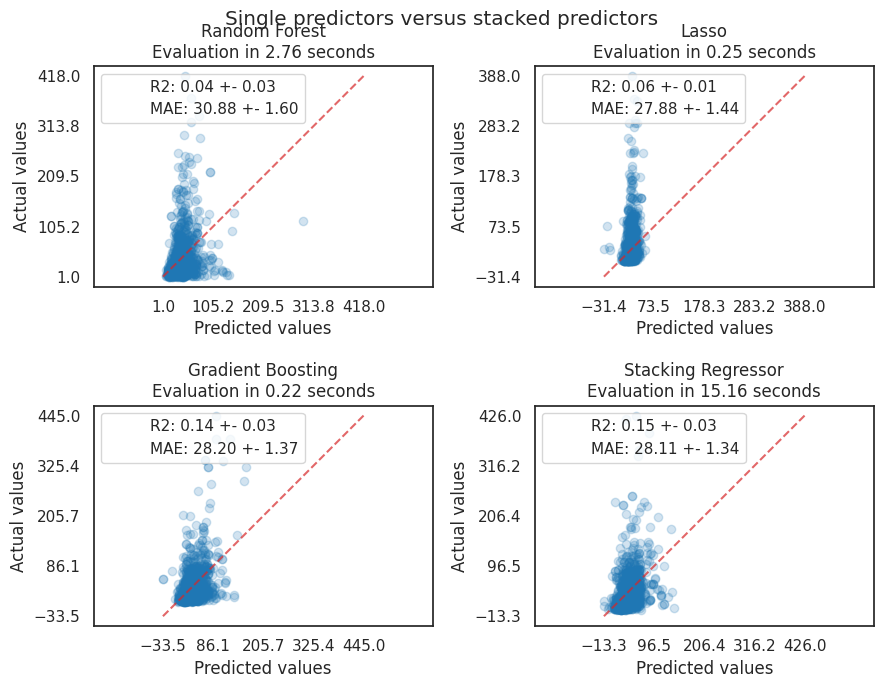

In [122]:
# X.shape -> (3363, 42)
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
axs = np.ravel(axs)

for ax, (name, est) in zip(
    axs, estimators + [("Stacking Regressor", stacking_regressor)]
):
    scorers = {"R2": "r2", "MAE": "neg_mean_absolute_error"}

    start_time = time.time()
    scores = cross_validate(
        est, X, y, scoring=list(scorers.values()), n_jobs=-1, verbose=0
    )
    elapsed_time = time.time() - start_time

    y_pred = cross_val_predict(est, X, y, n_jobs=-1, verbose=0)
    scores = {
        key: (
            f"{np.abs(np.mean(scores[f'test_{value}'])):.2f} +- "
            f"{np.std(scores[f'test_{value}']):.2f}"
        )
        for key, value in scorers.items()
    }

    display = PredictionErrorDisplay.from_predictions(
        y_true=y,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=ax,
        scatter_kwargs={"alpha": 0.2, "color": "tab:blue"},
        line_kwargs={"color": "tab:red"},
    )
    ax.set_title(f"{name}\nEvaluation in {elapsed_time:.2f} seconds")

    for name, score in scores.items():
        ax.plot([], [], " ", label=f"{name}: {score}")
    ax.legend(loc="upper left")

plt.suptitle("Single predictors versus stacked predictors")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

HistGradientBoostingRegressor(random_state=0)

## Recursive Feature Elimination Stacking feature Experiment

DecisionTreeRegressor Optimal number of features: 2
SVR Optimal number of features: 13
RandomForestRegressor Optimal number of features: 2
LassoCV Optimal number of features: 21


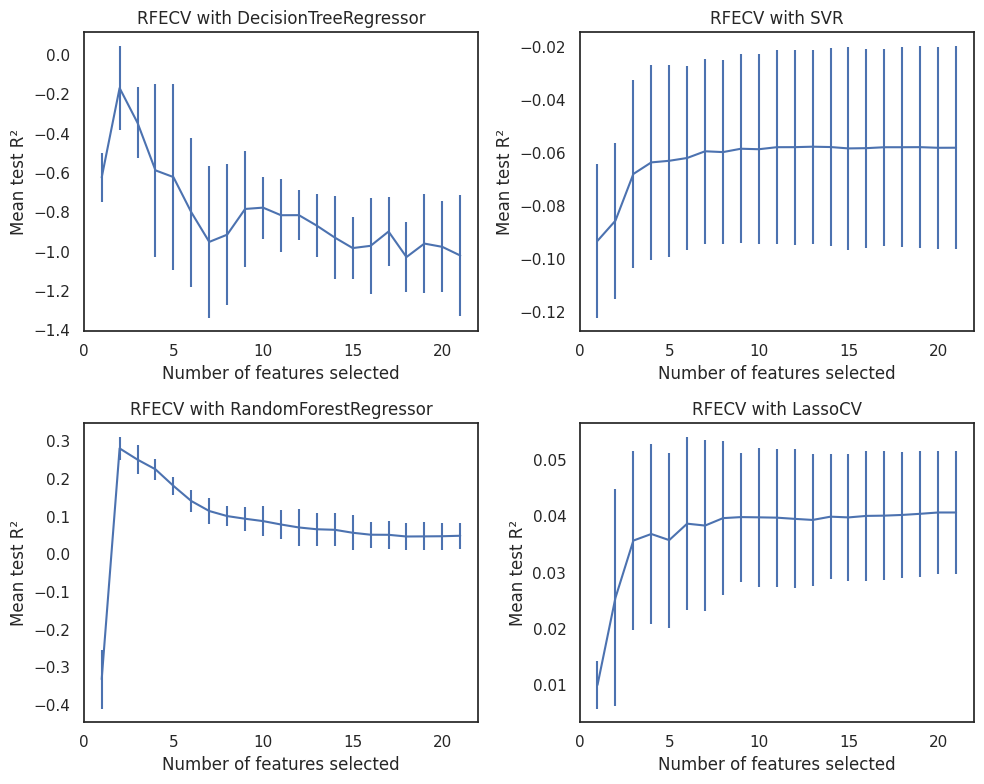

In [128]:
# models
dt = DecisionTreeRegressor()
svr = SVR(kernel="linear")
rf = RandomForestRegressor(random_state=42)
lasso_cv = LassoCV()

models = [dt, svr, rf, lasso_cv]

# Minimum number of features
min_features_to_select = 1  
cv = KFold(5, shuffle=True, random_state=42)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = np.ravel(axs)  # Flatten the 2x2 grid

for i, model in enumerate(models):
    rfecv = RFECV(
        estimator=model,
        step=1,
        cv=cv,
        scoring="r2",
        min_features_to_select=min_features_to_select,
        n_jobs=-1,
    )

    # Fit RFECV
    rfecv.fit(gbdt_pipeline[:-1].fit_transform(X), y)

    print(f"{model.__class__.__name__} Optimal number of features: {rfecv.n_features_}")

    # Extract CV results
    cv_results = pd.DataFrame(rfecv.cv_results_)

    # Plot on corresponding subplot
    axs[i].errorbar(
        x=cv_results["n_features"],
        y=cv_results["mean_test_score"],
        yerr=cv_results["std_test_score"],
    )
    axs[i].set_xlabel("Number of features selected")
    axs[i].set_ylabel("Mean test R²")
    axs[i].set_title(f"RFECV with {model.__class__.__name__}")

plt.tight_layout()
plt.show()


Sample all data to determine the informative features from the best models using RFECV

In [153]:
X_train.shape, X_train_sample.shape, X_test_sample.shape

((112086, 42), (11209, 42), (3114, 42))

In [157]:
min_features_to_select = 1  # Minimum number of features to consider
cv = KFold(5, shuffle=True, random_state=42)

rfecv_best = RFECV(
    estimator=rf,
    step=1,
    cv=cv,
    scoring="r2",
    min_features_to_select=min_features_to_select,
    n_jobs=-1,
)
rfecv_best.fit(gbdt_pipeline[:-1].fit_transform(X_train_sample), y_train_sample)

RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
      estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
      scoring='r2')

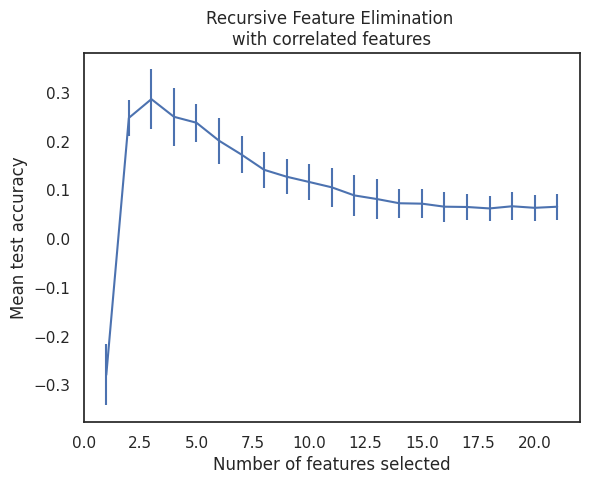

In [159]:
cv_results = pd.DataFrame(rfecv_best.cv_results_)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [161]:
print(f"Optimal number of features: {rfecv_best.n_features_}")
rfecv_best.ranking_

Optimal number of features: 3


array([18, 19,  1,  1,  7, 17, 16,  5, 14, 13, 10, 11,  6,  8, 15, 12,  3,
        1,  2,  4,  9])

Test recursive feature stacking in pipeline

In [ ]:
from sklearn.feature_selection import RFE

In [177]:
rf_pipeline_rfe = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', rf)
])

gbdt_pipeline_rfe = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', gbr)
])

In [178]:
gbdt_pipeline_rfe

Pipeline(steps=[('data_preparation',
                 Pipeline(steps=[('drop_columns',
                                  FunctionTransformer(func=<function drop_cat_features at 0x7591078ef740>)),
                                 ('replace_none',
                                  FunctionTransformer(func=<function replace_none_with_nan at 0x7591078ec540>)),
                                 ('convert_2numeric',
                                  FunctionTransformer(func=<function convert_columns_to_numeric at 0x7591078edee0>))])),
                ('data_preprocess...
                                                                                                     'number_of_images',
                                                                                                     'advert_quality'])])),
                                                                  ('scaler',
                                                                   PowerTransformer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x759107eb7910>)])),
                ('rfe',
                 RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=RandomForestRegressor(random_state=42),
                       n_jobs=-1, scoring='r2')),
                ('regressor_pipeline',
                 HistGradientBoostingRegressor(random_state=0))])

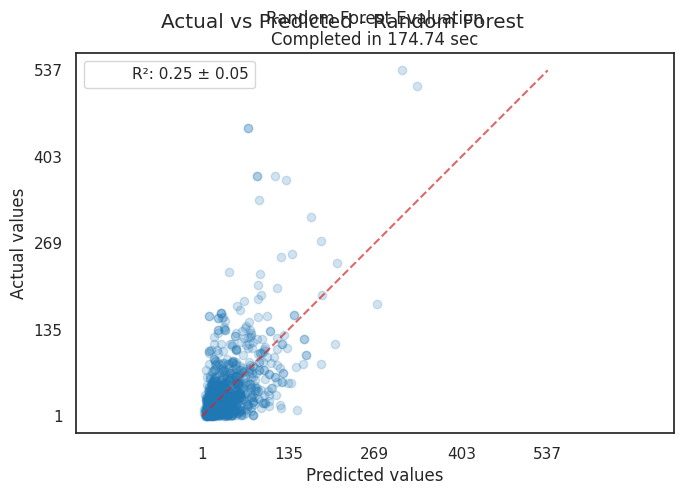

In [172]:
# Fit the Random Forest pipeline
rf_pipeline_rfe.fit(X_train_sample, y_train_sample)

# Define the single R² scoring metric
scoring_metric = "r2"

# Cross-validation and timing
start_time = time.time()
scores = crosrs_validate(
    rf_pipeline_rfe, X_train_sample, y_train_sample, scoring=scoring_metric, n_jobs=-1, verbose=0
)
elapsed_time = time.time() - start_time

# Get cross-validated predictions
y_pred = cross_val_predict(rf_pipeline_rfe, X_test_sample, y_test_sample, n_jobs=-1, verbose=0)

# Compute R² score mean and standard deviation
r2_mean = np.mean(scores["test_score"])
r2_std = np.std(scores["test_score"])
r2_score_text = f"R²: {r2_mean:.2f} ± {r2_std:.2f}"

# Initialize plot
fig, ax = plt.subplots(figsize=(7, 5))

# Plot actual vs predicted
display = PredictionErrorDisplay.from_predictions(
    y_true=y_test_sample,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    ax=ax,
    scatter_kwargs={"alpha": 0.2, "color": "tab:blue"},
    line_kwargs={"color": "tab:red"},
)
ax.set_title(f"Random Forest Evaluation\nCompleted in {elapsed_time:.2f} sec")

# Add R² score to legend
ax.plot([], [], " ", label=r2_score_text)
ax.legend(loc="upper left")

# Display plot
plt.suptitle("Actual vs Predicted - Random Forest")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


## Comparing RF vs GB with future selection

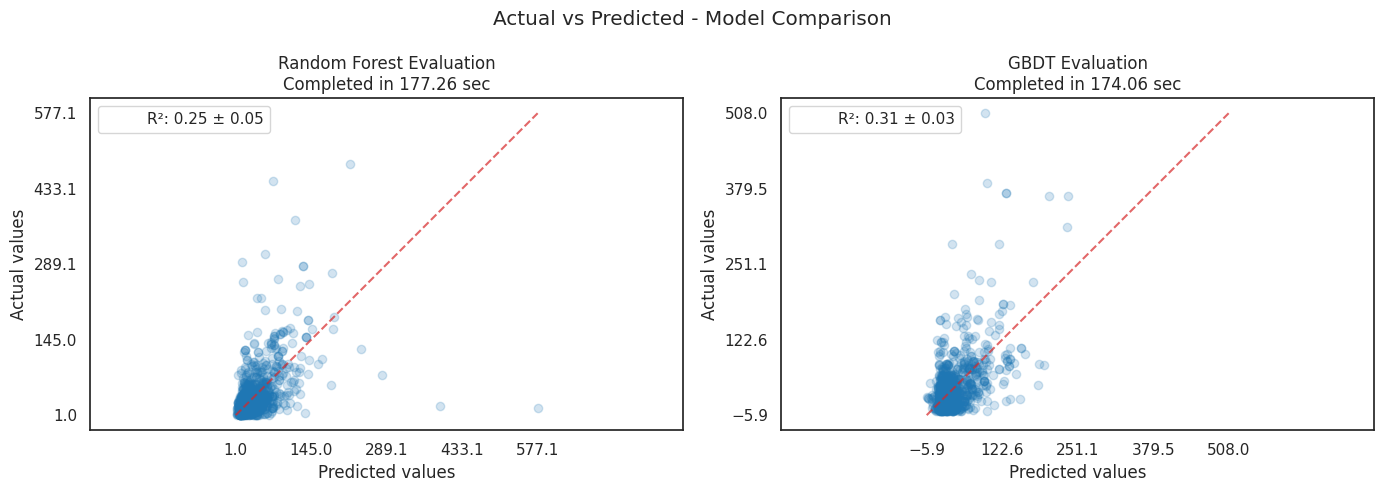

In [180]:
# Define models
models = {
    "Random Forest": rf_pipeline_rfe,
    "GBDT": gbdt_pipeline_rfe,
}

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    # Fit the model
    model.fit(X_train_sample, y_train_sample)

    # Cross-validation and timing
    start_time = time.time()
    scores = cross_validate(model, X_train_sample, y_train_sample, scoring="r2", n_jobs=-1, verbose=0)
    elapsed_time = time.time() - start_time

    # Get cross-validated predictions
    y_pred = cross_val_predict(model, X_test_sample, y_test_sample, n_jobs=-1, verbose=0)

    # Compute R² score mean and standard deviation
    r2_mean = np.mean(scores["test_score"])
    r2_std = np.std(scores["test_score"])
    r2_score_text = f"R²: {r2_mean:.2f} ± {r2_std:.2f}"

    # Plot actual vs predicted
    PredictionErrorDisplay.from_predictions(
        y_true=y_test_sample,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=ax,
        scatter_kwargs={"alpha": 0.2, "color": "tab:blue"},
        line_kwargs={"color": "tab:red"},
    )
    
    ax.set_title(f"{name} Evaluation\nCompleted in {elapsed_time:.2f} sec")

    # Add R² score to legend
    ax.plot([], [], " ", label=r2_score_text)
    ax.legend(loc="upper left")

# Display plots
plt.suptitle("Actual vs Predicted - Model Comparison")
plt.tight_layout()
plt.show()


## Feature Importance

Numerical feature importance

In [404]:
rf_pipeline_num = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf)
])

In [405]:
rf_pipeline_num.fit(X_train_sample, y_train_sample)

Pipeline(steps=[('data_preparation',
                 Pipeline(steps=[('drop_columns',
                                  FunctionTransformer(func=<function drop_features at 0x7591614f0a40>)),
                                 ('replace_none',
                                  FunctionTransformer(func=<function replace_none_with_nan at 0x7591614f04a0>)),
                                 ('convert_2numeric',
                                  FunctionTransformer(func=<function convert_columns_to_numeric at 0x7591614f0cc0>))])),
                ('data_preprocessor',...
                                                                                                     'boot_space_seats_up_litres',
                                                                                                     'insurance_group',
                                                                                                     'plate',
                                                                                                     'odometer_reading_miles',
                                                                                                     'adjusted_retail_amount_gbp',
                                                                                                     'predicted_mileage',
                                                                                                     'number_of_images',
                                                                                                     'advert_quality'])])),
                                                                  ('scaler',
                                                                   PowerTransformer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x75919842b950>)])),
                ('regressor_pipeline', RandomForestRegressor(random_state=42))])

In [293]:
# rf_pipeline_rfe.fit(X_train_sample, y_train_sample)
# print(f'Train score {rf_pipeline_rfe.score(X_train_sample, y_train_sample)}')
# print(f'Test score {rf_pipeline_rfe.score(X_test_sample, y_test_sample)}')

Train score 0.8956299939123494
Test score 0.30101318243300546


In [406]:
print(f'Train score {rf_pipeline_num.score(X_train_sample, y_train_sample)}')
print(f'Test score {rf_pipeline_num.score(X_test_sample, y_test_sample)}')

Train score 0.8705355420306875
Test score 0.1463925815212096


In [407]:
X_train_sample.shape

(5604, 42)

In [408]:
feature_names = rf_pipeline_num.named_steps["data_preprocessor"].get_feature_names_out()
feature_importance = rf_pipeline_num[-1].feature_importances_

mdi_importances = pd.Series(
    feature_importance, index=feature_names
).sort_values(ascending=True)

/tmp/ipykernel_8098/1347216174.py:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  ax.figure.tight_layout()


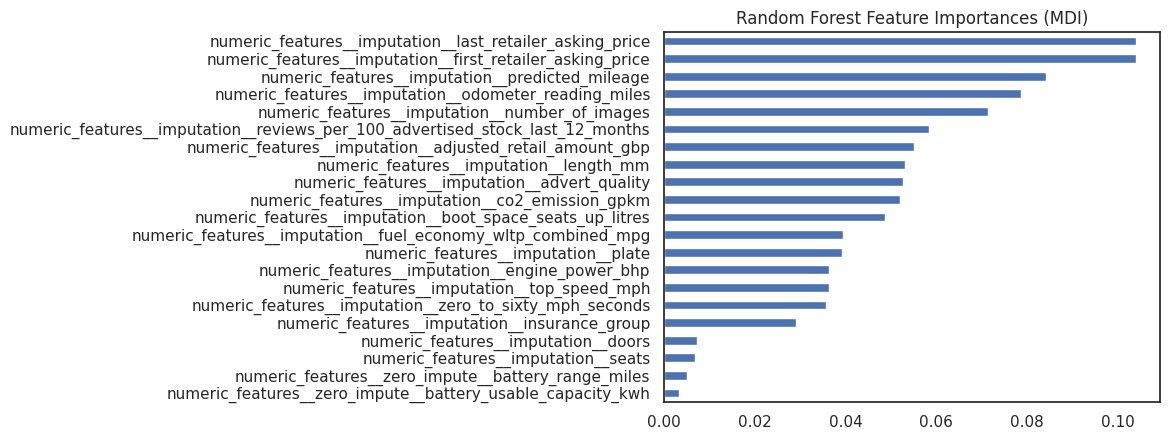

In [409]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

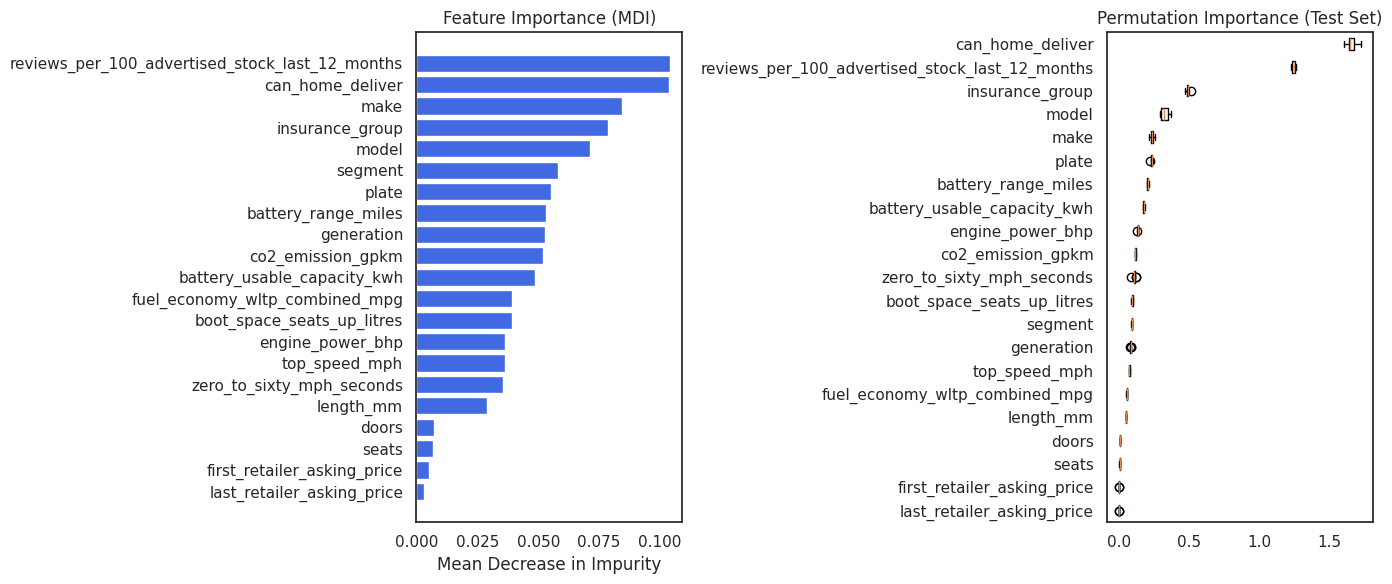

In [410]:
# Ensure DEFAULT_COLS_DROP is defined or remove it if not needed
df = X_train_sample.copy()
df_new = df.drop(DEFAULT_COLS_DROP, axis=1) if "DEFAULT_COLS_DROP" in globals() else df

# Extract feature importance from the final model in the pipeline
rf_model = rf_pipeline_num.named_steps["regressor_pipeline"]

# Compute MDI feature importance
feature_importance = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(len(sorted_idx)) + 0.5

# Compute permutation importance
result = permutation_importance(
    rf_model, rf_pipeline_num[:-1].fit_transform(df_new),  # Ensure proper transformation
    y_train_sample, n_repeats=10, random_state=42, n_jobs=-1
)
sorted_perm_idx = result.importances_mean.argsort()

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot MDI Feature Importance
axes[0].barh(pos, feature_importance[sorted_idx], align="center", color="royalblue")
axes[0].set_yticks(pos)
axes[0].set_yticklabels(np.array(df_new.columns)[sorted_idx])
axes[0].set_title("Feature Importance (MDI)")
axes[0].set_xlabel("Mean Decrease in Impurity")

tick_labels_dict = {"tick_labels": np.array(df_new.columns)[sorted_perm_idx]}

# Plot Permutation Importance
axes[1].boxplot(result.importances[sorted_perm_idx].T, vert=False, **tick_labels_dict)
axes[1].set_title("Permutation Importance (Test Set)")

# Adjust layout and show plots
plt.tight_layout()
plt.show()


Top features with RFE

In [319]:
gbdt_pipeline_rfe.fit(X_train_sample, y_train_sample)
print(f'Train score {gbdt_pipeline_rfe.score(X_train_sample, y_train_sample)}')
print(f'Test score {gbdt_pipeline_rfe.score(X_test_sample, y_test_sample)}')

Train score 0.5114481978250836
Test score 0.3490185760405403


In [318]:
rf_pipeline_num_rfe = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', rf)
])

rf_pipeline_num_rfe.fit(X_train_sample, y_train_sample)
print(f'Train score {rf_pipeline_num_rfe.score(X_train_sample, y_train_sample)}')
print(f'Test score {rf_pipeline_num_rfe.score(X_test_sample, y_test_sample)}')

Train score 0.8956299939123494
Test score 0.30101318243300546


# Target transformation Experiment

## GB on target transformation

In [67]:
y_pred_notrans = model_pipeline_notrans.predict(X_train)
y_pred_trans = model_pipeline_trans.predict(X_train)

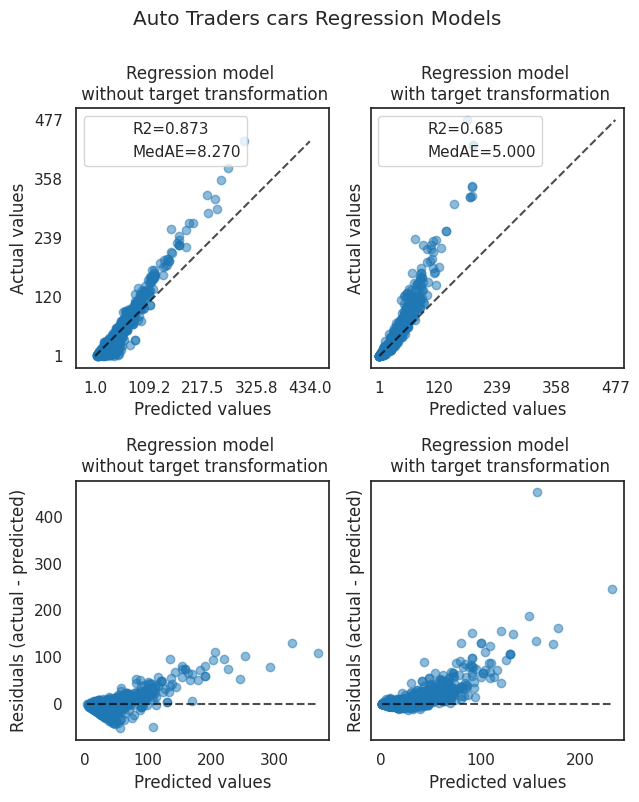

In [69]:

f, (ax0, ax1) = plt.subplots(2, 2, sharey="row", figsize=(6.5, 8))

# plot the actual vs predicted values
PredictionErrorDisplay.from_predictions(
    y_train,
    y_pred_notrans,
    kind="actual_vs_predicted",
    ax=ax0[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_train,
    y_pred_trans,
    kind="actual_vs_predicted",
    ax=ax0[1],
    scatter_kwargs={"alpha": 0.5},
)

# Add the score in the legend of each axis
for ax, y_pred in zip([ax0[0], ax0[1]], [y_pred_notrans, y_pred_trans]):
    for name, score in compute_score(y_train, y_pred).items():
        ax.plot([], [], " ", label=f"{name}={score}")
    ax.legend(loc="upper left")

ax0[0].set_title("Regression model \n without target transformation")
ax0[1].set_title("Regression model \n with target transformation")

# plot the residuals vs the predicted values
PredictionErrorDisplay.from_predictions(
    y_train,
    y_pred_notrans,
    kind="residual_vs_predicted",
    ax=ax1[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_train,
    y_pred_trans,
    kind="residual_vs_predicted",
    ax=ax1[1],
    scatter_kwargs={"alpha": 0.5},
)
ax1[0].set_title("Regression model \n without target transformation")
ax1[1].set_title("Regression model \n with target transformation")

f.suptitle("Auto Traders cars Regression Models", y=1.0)
plt.tight_layout()
plt.show()

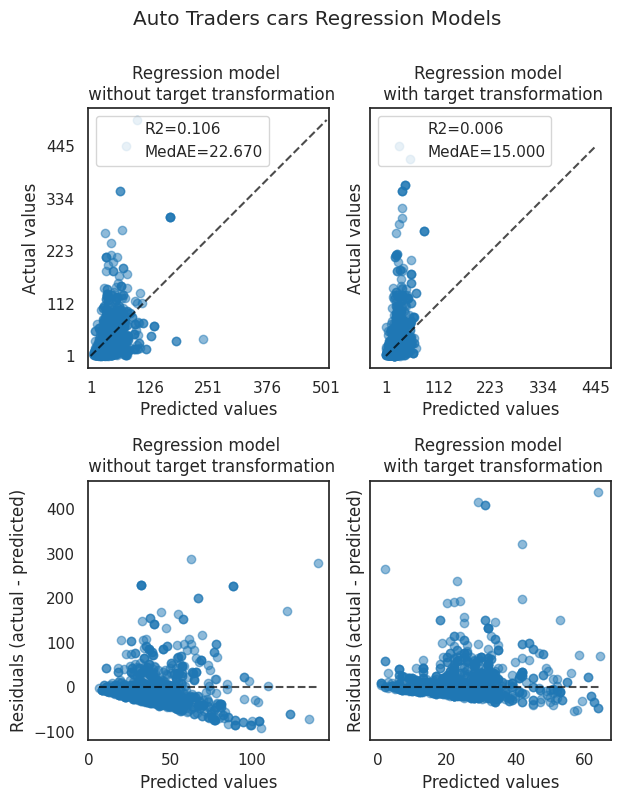

In [48]:

f, (ax0, ax1) = plt.subplots(2, 2, sharey="row", figsize=(6.5, 8))

# plot the actual vs predicted values
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_notrans,
    kind="actual_vs_predicted",
    ax=ax0[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_trans,
    kind="actual_vs_predicted",
    ax=ax0[1],
    scatter_kwargs={"alpha": 0.5},
)

# Add the score in the legend of each axis
for ax, y_pred in zip([ax0[0], ax0[1]], [y_pred_notrans, y_pred_trans]):
    for name, score in compute_score(y_t, y_pred).items():
        ax.plot([], [], " ", label=f"{name}={score}")
    ax.legend(loc="upper left")

ax0[0].set_title("Regression model \n without target transformation")
ax0[1].set_title("Regression model \n with target transformation")

# plot the residuals vs the predicted values
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_notrans,
    kind="residual_vs_predicted",
    ax=ax1[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_trans,
    kind="residual_vs_predicted",
    ax=ax1[1],
    scatter_kwargs={"alpha": 0.5},
)
ax1[0].set_title("Regression model \n without target transformation")
ax1[1].set_title("Regression model \n with target transformation")

f.suptitle("Auto Traders cars Regression Models", y=1.0)
plt.tight_layout()
plt.show()